In [17]:
# CELL 1: Environment Setup (Run this first)
%load_ext autoreload
%autoreload 2

import sys
import numpy as np

repo_root = r"c:\Users\melvi\Documents\XGBoostLSS"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Numpy 2.0 monkeypatch
if not hasattr(np, 'obj2sctype'):
    np.obj2sctype = lambda obj, default=np.object_: np.dtype(obj).type
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from xgboostlss.model import *
from xgboostlss.distributions.ZOIB import *
from xgboostlss.distributions.ZOIK import *
from xgboostlss.datasets.data_loader import load_simulated_ZOIB_data

import pandas as pd
import multiprocessing
import plotnine

plotnine.options.figure_size = (18, 9)
n_cpu = multiprocessing.cpu_count()

In [19]:
train, test = load_simulated_ZOIB_data()
n_cpu = multiprocessing.cpu_count()

X_train, y_train = train.drop(columns=["lgd"]), train["lgd"].values
X_test, y_test = test.drop(columns=["lgd"]), test["lgd"].values

dtrain = xgb.DMatrix(X_train, label=y_train, nthread=n_cpu)
dtest = xgb.DMatrix(X_test, nthread=n_cpu)

In [42]:
xgblss = XGBoostLSS(
    ZOIB(stabilization="None",  
             response_fn="softplus",      
             loss_fn="nll"          
            )
)

In [43]:
param_dict = {
    "eta":              ["float", {"low": 1e-5,   "high": 1,     "log": True}],
    "max_depth":        ["int",   {"low": 1,      "high": 10,    "log": False}],
    "gamma":            ["float", {"low": 1e-8,   "high": 40,    "log": True}],
    "subsample":        ["float", {"low": 0.2,    "high": 1.0,   "log": False}],
    "colsample_bytree": ["float", {"low": 0.2,    "high": 1.0,   "log": False}],
    "min_child_weight": ["float", {"low": 1e-8,   "high": 500,   "log": True}],
    "booster":          ["categorical", ["gbtree"]]
}

np.random.seed(123)
opt_param = xgblss.hyper_opt(param_dict,
                             dtrain,
                             num_boost_round=100,        # Number of boosting iterations.
                             nfold=5,                    # Number of cv-folds.
                             early_stopping_rounds=20,   # Number of early-stopping rounds
                             max_minutes=15,             # Time budget in minutes, i.e., stop study after the given number of minutes.
                             n_trials=30 ,               # The number of trials. If this argument is set to None, there is no limitation on the number of trials.
                             silence=False,              # Controls the verbosity of the trail, i.e., user can silence the outputs of the trail.
                             seed=123,                   # Seed used to generate cv-folds.
                             hp_seed=123                 # Seed for random number generator used in the Bayesian hyperparameter search.
                            )

[I 2026-05-10 20:16:09,432] A new study created in memory with name: XGBoostLSS Hyper-Parameter Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-10 20:16:48,961] Trial 0 finished with value: 346.4920164 and parameters: {'eta': 0.030363087280807707, 'max_depth': 3, 'gamma': 1.5074442732613943e-06, 'subsample': 0.6410518152663129, 'colsample_bytree': 0.7755751758284506, 'min_child_weight': 0.00033635921133357536, 'booster': 'gbtree'}. Best is trial 0 with value: 346.4920164.
[I 2026-05-10 20:17:19,743] Trial 1 finished with value: -233.8414612 and parameters: {'eta': 0.8013476947482925, 'max_depth': 7, 'gamma': 0.0004148938237251032, 'subsample': 0.5136940145553204, 'colsample_bytree': 0.47454241292069554, 'min_child_weight': 0.6310749636830225, 'booster': 'gbtree'}. Best is trial 1 with value: -233.8414612.
[I 2026-05-10 20:18:57,355] Trial 2 finished with value: 4232.928222799999 and parameters: {'eta': 0.0015590542353378792, 'max_depth': 1, 'gamma': 6.638115717563432e-05, 'subsample': 0.7903963245856287, 'colsample_bytree': 0.3459933843628, 'min_child_weight': 7.536211465592933e-07, 'booster': 'gbtree'}. Best is tri

In [44]:
# Hyper-Parameter Optimization successfully finished.
#   Number of finished trials:  16
#   Best trial:
#     Value: -840.9163940000001
#     Params: 
#     eta: 0.17844445339780937
#     max_depth: 2
#     gamma: 1.4065656445208353e-08
#     subsample: 0.21850474164267583
#     colsample_bytree: 0.9979013632487389
#     min_child_weight: 3.821821904867193e-05
#     booster: gbtree
#     opt_rounds: 100

In [45]:
np.random.seed(123)

opt_params = opt_param.copy()
n_rounds = opt_params["opt_rounds"]
del opt_params["opt_rounds"]

# Train Model with optimized hyperparameters
xgblss.train(opt_params,
             dtrain,
             num_boost_round=n_rounds
             )

In [46]:
# Set seed for reproducibility
torch.manual_seed(123)

# Number of samples to draw from predicted distribution
n_samples = 1000
quant_sel = [0.05, 0.95] # Quantiles to calculate from predicted distribution

# Sample from predicted distribution
pred_samples = xgblss.predict(dtest,
                              pred_type="samples",
                              n_samples=n_samples,
                              seed=123)

# Calculate quantiles from predicted distribution
pred_quantiles = xgblss.predict(dtest,
                                pred_type="quantiles",
                                n_samples=n_samples,
                                quantiles=quant_sel)

# Return predicted distributional parameters
pred_params = xgblss.predict(dtest,
                             pred_type="parameters")

In [47]:
pred_samples

,y_sample0,y_sample1,y_sample2,y_sample3,y_sample4,y_sample5,y_sample6,y_sample7,y_sample8,y_sample9,...,y_sample990,y_sample991,y_sample992,y_sample993,y_sample994,y_sample995,y_sample996,y_sample997,y_sample998,y_sample999
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.000000,1.000000,1.000000,0.959069,1.000000,1.000000,0.942875,1.000000,0.999999,1.000000,...,0.999997,1.000000,1.000000,1.000000,0.985776,1.000000,0.956777,1.000000,0.947531,1.000000
3,0.945258,0.989407,0.949787,0.931733,0.993271,0.969750,0.971098,0.957072,0.985728,0.913889,...,0.984392,0.979886,0.950178,0.927561,0.988618,0.969985,0.931896,0.979621,0.982008,0.998528
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.687528,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.570927,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5530,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.081032,0.000000,0.000000,0.000000,0.000000,0.000000,0.507521
5531,0.765321,0.773871,1.000000,1.000000,0.553445,0.595762,0.392849,0.496331,1.000000,0.717334,...,1.000000,0.762304,1.000000,1.000000,0.502652,0.706787,0.864229,1.000000,1.000000,0.642699
5532,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5533,0.029772,0.000187,0.046257,0.001668,0.025790,0.003931,0.117324,0.014723,0.003484,0.001036,...,0.038927,0.000361,0.053172,0.159607,0.007221,0.198964,0.016568,0.009016,0.023805,0.110741


In [48]:
pred_samples.to_csv("pred_samples.csv", index=False)
pred_quantiles.to_csv("pred_quantiles.csv", index=False)
pred_params.to_csv("pred_params.csv", index=False)

In [49]:
pred_quantiles.head()

,quant_0.05,quant_0.95
0,0.000000,0.000000
1,0.488842,1.000000
2,0.926248,1.000000
3,0.889735,0.996689
4,0.402018,1.000000


In [50]:
pred_params.head()

,mu,phi,gate_zo,gate_one
0,0.120369,5.699492,0.976671,0.001839
1,0.404641,6.833052,0.926077,0.999000
2,0.960271,10.132047,0.720673,0.999000
3,0.954643,36.872280,0.027667,0.997952
4,0.560937,8.004958,0.854287,0.977716


In [ ]:
from plotnine import ggplot, aes, geom_density, facet_wrap, theme_bw, theme

pred_df = pd.melt(pred_samples.iloc[:,0:5])
actual_df = pd.DataFrame.from_dict({"variable": "ACTUAL", "value": y_test.reshape(-1,)})
plot_df = pd.concat([pred_df, actual_df])

(
    ggplot(plot_df, 
           aes(x="value",
               color="variable",
               fill="variable")) +  
    geom_density(alpha=0.4) + 
    facet_wrap("variable",
              scales="free_y",
              ncol=2) + 
    theme_bw(base_size=15) + 
    theme(legend_position="none")
)

NameError: name 'ggplot' is not defined

<Figure size 1000x800 with 0 Axes>

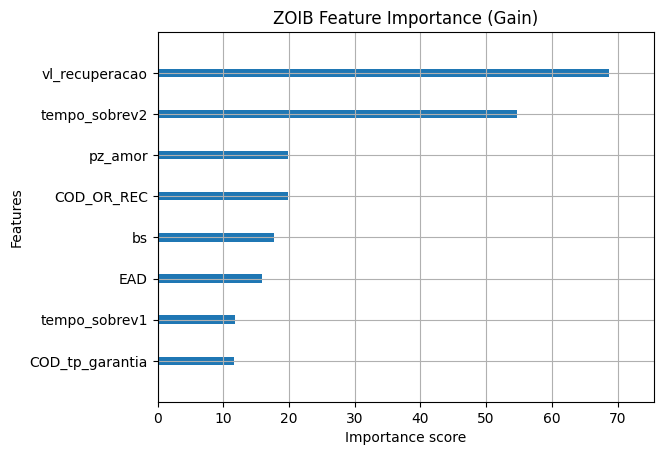

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get the underlying booster from the trained XGBoostLSS model
booster = xgblss.booster

# Plot the top 10 most important features across all 4 parameters
plt.figure(figsize=(10, 8))
xgb.plot_importance(booster, 
                    importance_type='gain', 
                    max_num_features=10, 
                    title="ZOIB Feature Importance (Gain)",
                    show_values=False)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score

# 1. Compute Mean Metrics
# The expected LGD is the average of the 1,000 Monte Carlo samples for each row
y_expected = pred_samples.mean(axis=1).values
rmse = np.sqrt(mean_squared_error(y_test, y_expected))
mae = mean_absolute_error(y_test, y_expected)

# 2. Compute Gate Metrics (How well did the model separate the 0s and 1s?)
is_zero = (y_test == 0).astype(int)
is_one = (y_test == 1).astype(int)

# gate_zo is the probability of being 0 or 1. 
# gate_one is the conditional probability of being 1 given it is discrete.
prob_one = pred_params['gate_zo'] * pred_params['gate_one']
prob_zero = pred_params['gate_zo'] * (1 - pred_params['gate_one'])

auc_zero = roc_auc_score(is_zero, prob_zero)
auc_one = roc_auc_score(is_one, prob_one)

print(f"--- Evaluation Metrics ---")
print(f"RMSE (Expected LGD vs Actual LGD): {rmse:.4f}")
print(f"MAE (Expected LGD vs Actual LGD):  {mae:.4f}")
print(f"AUC (Predicting exact 0s):         {auc_zero:.4f}")
print(f"AUC (Predicting exact 1s):         {auc_one:.4f}")

--- Evaluation Metrics ---
RMSE (Expected LGD vs Actual LGD): 0.0969
MAE (Expected LGD vs Actual LGD):  0.0507
AUC (Predicting exact 0s):         0.9623
AUC (Predicting exact 1s):         0.9798


In [ ]:
import numpy as np

def calculate_crps(y_true, y_samples):
    """
    Calculates the empirical Continuous Ranked Probability Score (CRPS)
    using the exact logic from the XGBoostLSS PyTorch implementation.
    """
    # Format inputs
    y = np.array(y_true).reshape(-1)
    
    # Transpose samples to shape (n_samples, n_observations)
    yhat_dist = np.array(y_samples).T
    n_samples = yhat_dist.shape[0]

    # Sort the forecasts in ascending order for each observation
    yhat_dist_sorted = np.sort(yhat_dist, axis=0)

    # Initialize tracking arrays
    y_cdf = np.zeros_like(y, dtype=float)
    yhat_cdf = np.zeros_like(y, dtype=float)
    yhat_prev = np.zeros_like(y, dtype=float)
    crps = np.zeros_like(y, dtype=float)

    # Calculate empirical CDF differences
    for yhat in yhat_dist_sorted:
        flag = (y_cdf == 0) & (y < yhat)
        crps += flag * ((y - yhat_prev) * yhat_cdf ** 2)
        crps += flag * ((yhat - y) * (yhat_cdf - 1) ** 2)
        crps += (~flag) * ((yhat - yhat_prev) * (yhat_cdf - y_cdf) ** 2)
        y_cdf += flag
        yhat_cdf += 1 / n_samples
        yhat_prev = yhat

    # In case actual y is greater than all predicted samples
    flag = (y_cdf == 0)
    crps += flag * (y - yhat_prev)

    return crps.mean()

# Run it on your memory variables
mean_crps = calculate_crps(y_test, pred_samples.values)
print(f"Mean CRPS: {mean_crps:.4f}")

Mean CRPS: 0.0273


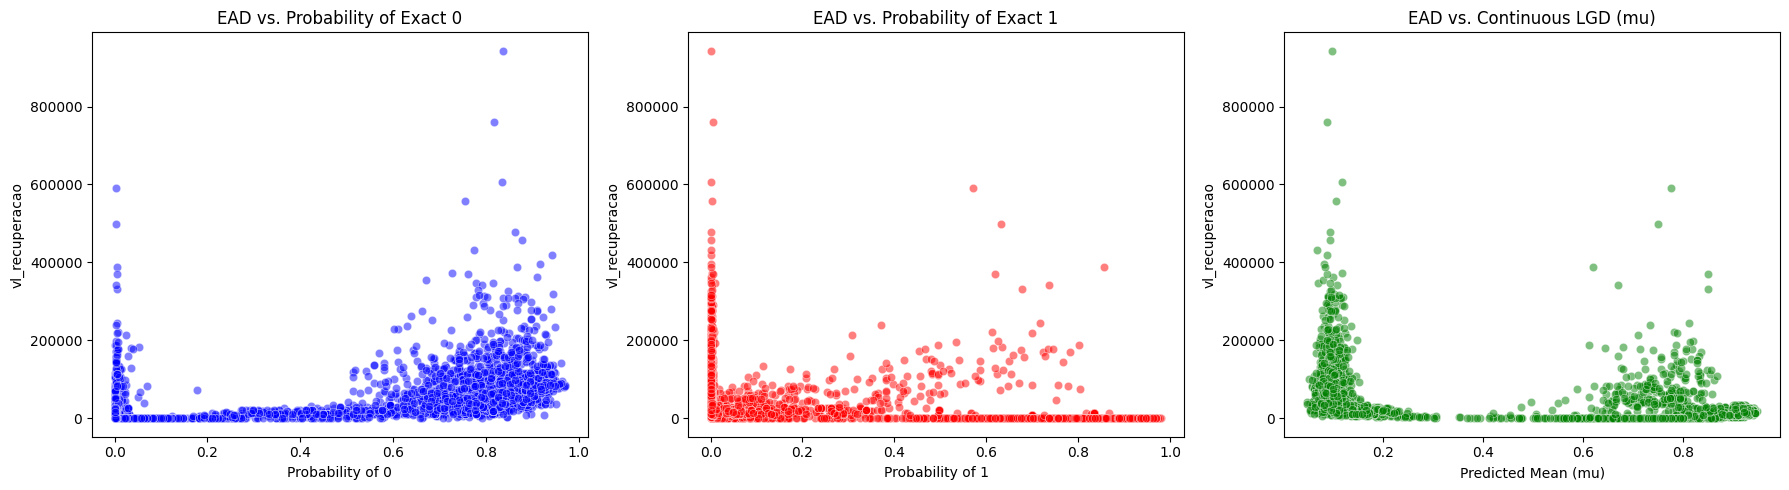

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the absolute probability of being exactly 0 or exactly 1
prob_exact_zero = pred_params['gate_zo'] * (1 - pred_params['gate_one'])
prob_exact_one = pred_params['gate_zo'] * pred_params['gate_one']

# Create a clean combined DataFrame for plotting
# .values ensures alignment in case the indices of X_test and pred_params don't match perfectly
plot_df = pd.DataFrame({
    'vl_recuperacao': X_test['vl_recuperacao'].values,
    'Probability of 0': prob_exact_zero.values,
    'Probability of 1': prob_exact_one.values,
    'Predicted Mean (mu)': pred_params['mu'].values
})

# Plot Feature vs. Parameters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: How does EAD affect the chance of being exactly 0?
sns.scatterplot(data=plot_df, x='Probability of 0', y='vl_recuperacao', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('EAD vs. Probability of Exact 0')

# Plot 2: How does EAD affect the chance of being exactly 1?
sns.scatterplot(data=plot_df, x='Probability of 1', y='vl_recuperacao', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('EAD vs. Probability of Exact 1')

# Plot 3: How does EAD affect the continuous fraction?
sns.scatterplot(data=plot_df, x='Predicted Mean (mu)', y='vl_recuperacao', alpha=0.5, ax=axes[2], color='green')
axes[2].set_title('EAD vs. Continuous LGD (mu)')

plt.tight_layout()
plt.show()